# SCANIA Component X: Exploratory Data Analysis (EDA)

Questo notebook esplora il **SCANIA Component X Dataset**, un dataset reale rilasciato per l'Industrial Challenge dell'IDA 2024. I dati derivano da una flotta di camion della SCANIA (Svezia) e si concentrano sulla manutenzione predittiva (PdM) di un componente del motore anonimizzato ("Component X").

## 1. Caratteristiche del Dominio e Struttura Temporale
* **Tipo di Sistema**: Veicoli commerciali industriali operanti in condizioni reali, non simulati.
* **Dati Operativi (Multivariate Time Series)**: Letture estratte dalle unità di controllo del veicolo a intervalli di tempo specifici (identificati da `vehicle_id` e `time_step`).
* **Segnali Presenti**: I sensori non riportano solo valori continui tradizionali, ma sono strutturati in **contatori numerici** (valori cumulativi) e **istogrammi** (distribuzioni di valori in range specifici).
* **Variabile Target (TTE)**: Le etichette di training si trovano in `train_tte.csv`, che riporta due colonne chiave: `length_of_study_time_step` (i passi temporali di operatività) e `in_study_repair` (l'etichetta binaria di guasto/sostituzione).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile grafico
sns.set_theme(style='whitegrid', palette='muted')

# 1. Caricamento del set di etichette e riparazioni (Time-To-Event)
# Assicurati che il percorso del file corrisponda alla tua directory locale
print("Caricamento del file TTE in corso...")
train_tte = pd.read_csv('data/train_tte.csv')

print(f"Dimensioni del file TTE: {train_tte.shape}")
display(train_tte.head())

Caricamento del file TTE in corso...
Dimensioni del file TTE: (23550, 3)


,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


Conteggio delle classi:
Componenti sani (Label 0): 21278
Componenti riparati (Label 1): 2272


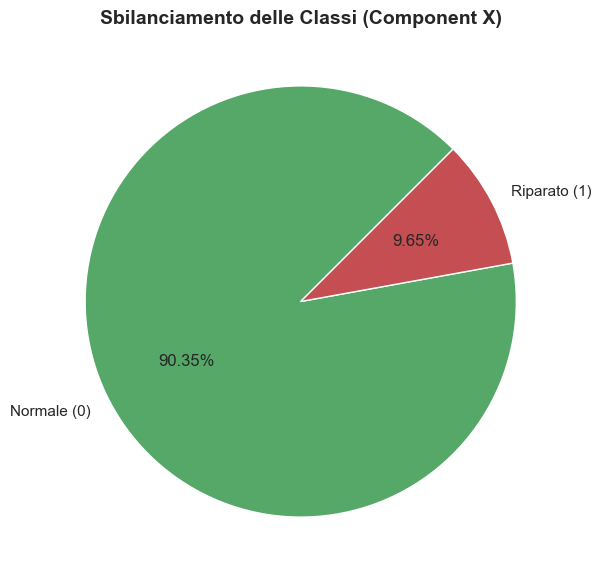

In [4]:
# Analisi dello sbilanciamento della colonna target 'in_study_repair'
class_counts = train_tte['in_study_repair'].value_counts()

print("Conteggio delle classi:")
print(f"Componenti sani (Label 0): {class_counts[0]}")
print(f"Componenti riparati (Label 1): {class_counts[1]}")

# Grafico a torta per mostrare lo sbilanciamento
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    class_counts, 
    labels=['Normale (0)', 'Riparato (1)'], 
    colors=['#55A868', '#C44E52'], 
    autopct='%1.2f%%', 
    startangle=45,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Sbilanciamento delle Classi (Component X)', fontsize=14, fontweight='bold')
plt.show()

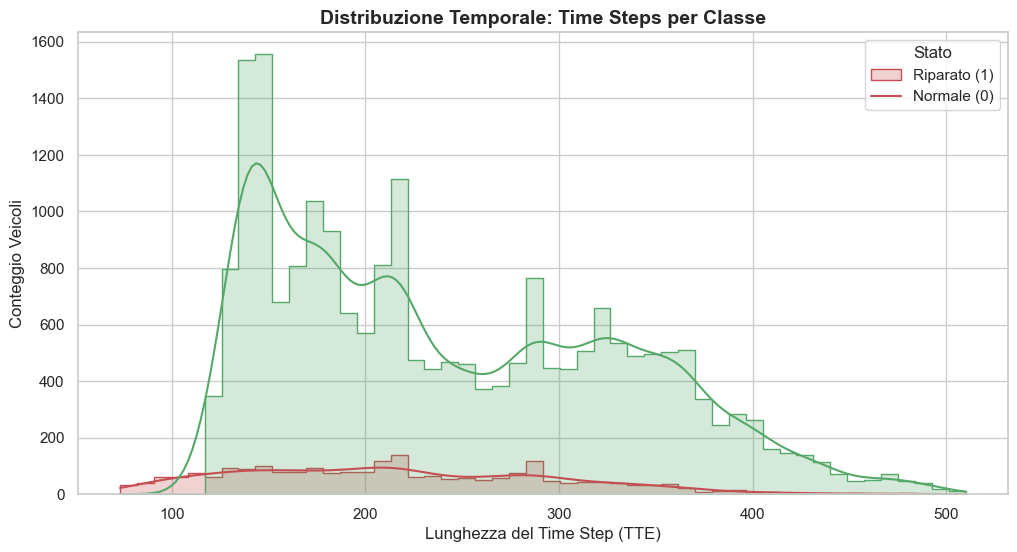

In [5]:
# Distribuzione della lunghezza dello studio temporale
plt.figure(figsize=(12, 6))
sns.histplot(
    data=train_tte, 
    x='length_of_study_time_step', 
    hue='in_study_repair', 
    bins=50, 
    kde=True, 
    palette=['#55A868', '#C44E52'],
    element='step'
)

plt.title('Distribuzione Temporale: Time Steps per Classe', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza del Time Step (TTE)', fontsize=12)
plt.ylabel('Conteggio Veicoli', fontsize=12)
plt.legend(title='Stato', labels=['Riparato (1)', 'Normale (0)'])
plt.show()

## 2. Esplorazione delle Specifiche Tecniche

In questa sezione analizziamo le configurazioni dei veicoli (`train_specifications.csv`). Vogliamo capire come è composta la flotta e, soprattutto, se determinate configurazioni tecniche o casi d'uso rendono il "Component X" più vulnerabile ai guasti.

In [7]:
# Caricamento delle specifiche dei veicoli
print("Caricamento del file Specifiche in corso...")
train_specs = pd.read_csv('data/train_specifications.csv')

print(f"Dimensioni del file Specifiche: {train_specs.shape}")
display(train_specs.head())

# Controllo dei valori mancanti nelle specifiche
missing_specs = train_specs.isnull().mean() * 100
missing_specs = missing_specs[missing_specs > 0].sort_values(ascending=False)

if not missing_specs.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_specs.index[:15], y=missing_specs.values[:15], palette='flare')
    plt.title('Valori Mancanti nelle Specifiche Tecniche (%)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('% Dati Mancanti')
    plt.show()
else:
    print("Nessun dato mancante rilevato nelle specifiche tecniche.")

Caricamento del file Specifiche in corso...
Dimensioni del file Specifiche: (23550, 9)


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


Nessun dato mancante rilevato nelle specifiche tecniche.


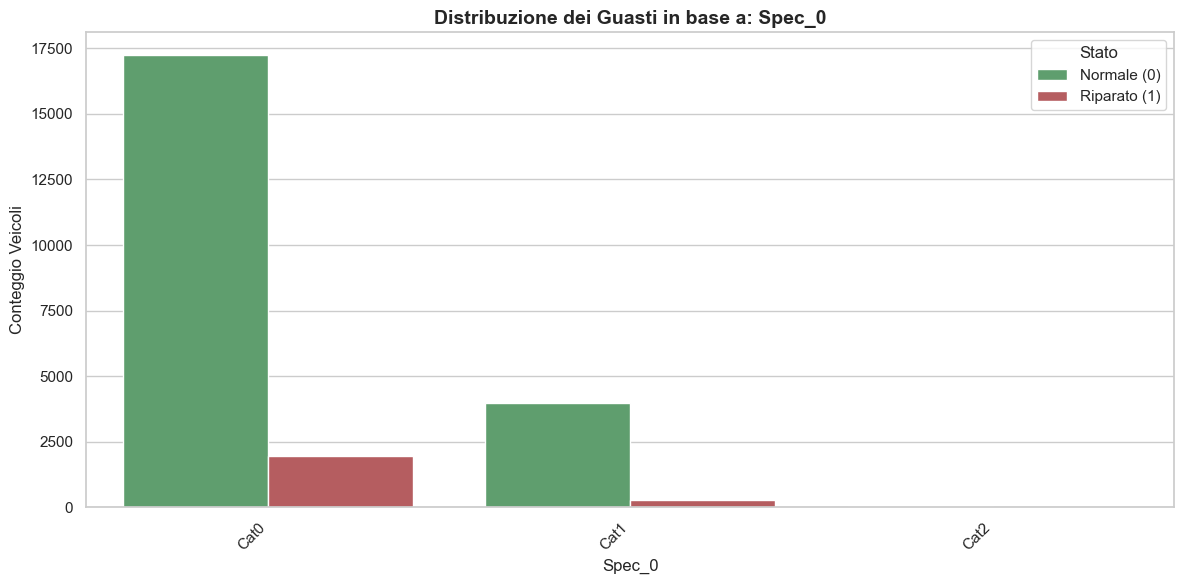

In [8]:
# Eseguiamo il merge tra Specifiche e Etichette TTE
df_specs_labels = pd.merge(train_specs, train_tte, on='vehicle_id', how='inner')

# Scegliamo una colonna categorica interessante (sostituisci 'equipment_class' o 'truck_type' 
# con una colonna reale visibile dal dataframe se diversa)
# Usiamo il primo nome di colonna categorica disponibile come esempio esplorativo
cat_col = df_specs_labels.select_dtypes(include=['object']).columns[0] 

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_specs_labels, 
    x=cat_col, 
    hue='in_study_repair', 
    palette=['#55A868', '#C44E52']
)

plt.title(f'Distribuzione dei Guasti in base a: {cat_col}', fontsize=14, fontweight='bold')
plt.xlabel(cat_col)
plt.ylabel('Conteggio Veicoli')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stato', labels=['Normale (0)', 'Riparato (1)'])
plt.tight_layout()
plt.show()

## 3. Esplorazione dei Dati Operativi (Sensori a Istogramma)

Il file `train_operational_readouts.csv` contiene l'effettivo "battito cardiaco" del componente. La SCANIA, per motivi di efficienza e privacy, aggrega i dati delle centraline (ECU) in due formati:
*   **Contatori (Counters)**: Valori che crescono nel tempo (es. chilometri totali, consumo totale).
*   **Istogrammi (Histograms)**: Array di bidoni (bins) che contano per quanto tempo il componente ha operato in una specifica condizione (es. per quanto tempo la temperatura è stata tra 80°C e 90°C).

In [10]:
print("Caricamento del file Dati Operativi in corso...")
train_op = pd.read_csv('data/train_operational_readouts.csv')

print(f"Dimensioni del file Dati Operativi: {train_op.shape}")
print(f"Numero di veicoli unici monitorati: {train_op['vehicle_id'].nunique()}")

# Mostriamo le prime righe per ispezionare il formato delle colonne anonimizzate
display(train_op.head())

# Identifichiamo le colonne che potrebbero appartenere a istogrammi
# Solitamente nel dataset SCANIA contengono parole chiave come 'bin' o suffissi numerici sequenziali
hist_columns = [col for col in train_op.columns if 'bin' in col.lower() or 'hist' in col.lower()]
print(f"\\nTrovate {len(hist_columns)} colonne che sembrano appartenere a istogrammi.")

Caricamento del file Dati Operativi in corso...
Dimensioni del file Dati Operativi: (1122452, 107)
Numero di veicoli unici monitorati: 23550


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0


\nTrovate 0 colonne che sembrano appartenere a istogrammi.


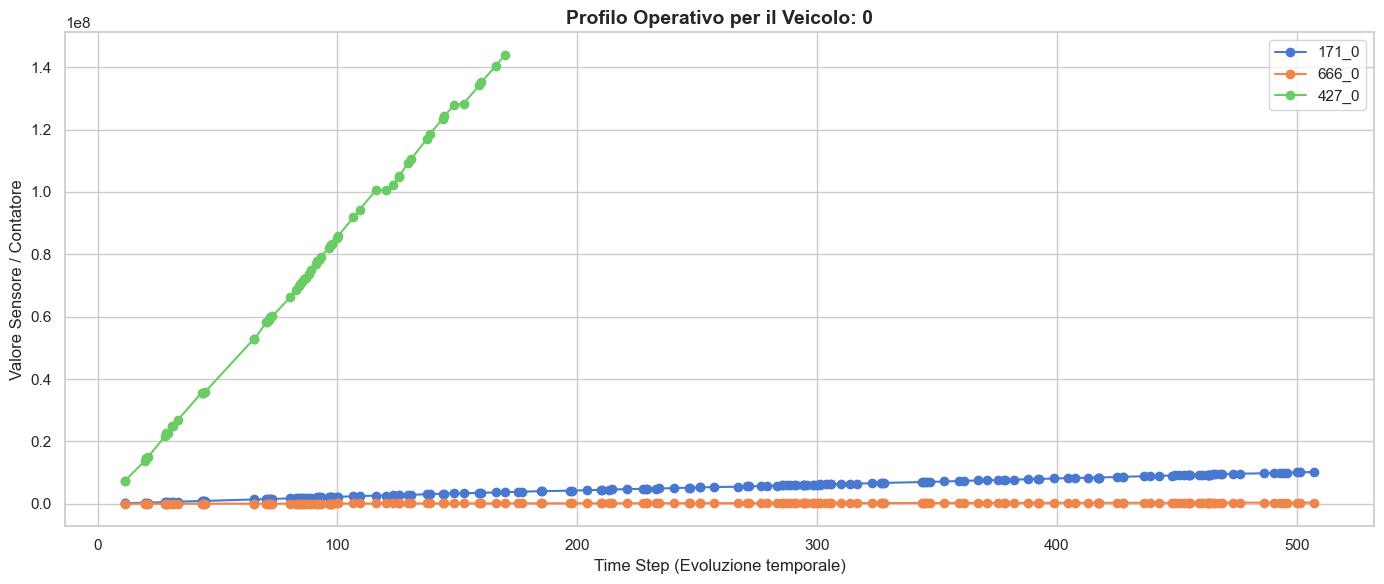

In [11]:
# Selezioniamo un vehicle_id a caso per visualizzarne il profilo
sample_vehicle = train_op['vehicle_id'].unique()[0]
df_sample = train_op[train_op['vehicle_id'] == sample_vehicle].sort_values('time_step')

# Scegliamo 3 variabili operative a caso (assumendo che ci siano colonne anonimizzate tipo var_1, var_2...)
# Adattiamo selezionando la terza, quarta e quinta colonna numerica (escludendo id e time_step)
cols_to_plot = df_sample.select_dtypes(include=[np.number]).columns[2:5]

plt.figure(figsize=(14, 6))
for col in cols_to_plot:
    plt.plot(df_sample['time_step'], df_sample[col], marker='o', label=col)

plt.title(f'Profilo Operativo per il Veicolo: {sample_vehicle}', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Evoluzione temporale)', fontsize=12)
plt.ylabel('Valore Sensore / Contatore', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Unione dei Dati (Merge) e Confronto Statistico

Per quantificare l'impatto fisico del degrado sul "Component X", dobbiamo incrociare i dati operativi dei sensori con lo stato di salute del veicolo. Eseguiremo un *merge* tra `train_operational_readouts` e `train_tte`.
Successivamente, utilizzeremo dei boxplot per confrontare le distribuzioni di alcune feature chiave tra i veicoli "Sani" (che non hanno subito riparazioni durante lo studio) e quelli "Riparati" (che hanno subito un guasto).

In [12]:
print("Unione dei Dati Operativi con le Etichette TTE in corso...")

# Eseguiamo il merge tra i dati dei sensori e la variabile target
df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')

print(f"Dimensioni del dataset unito: {df_merged.shape}")

# Verifichiamo che il merge sia andato a buon fine mostrando una porzione dei dati
display(df_merged[['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']].head())

Unione dei Dati Operativi con le Etichette TTE in corso...
Dimensioni del dataset unito: (1122452, 109)


,vehicle_id,time_step,length_of_study_time_step,in_study_repair
0,0,11.2,510.0,0
1,0,11.4,510.0,0
2,0,19.6,510.0,0
3,0,20.2,510.0,0
4,0,21.0,510.0,0


C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\258372398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\258372398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\258372398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\258372398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

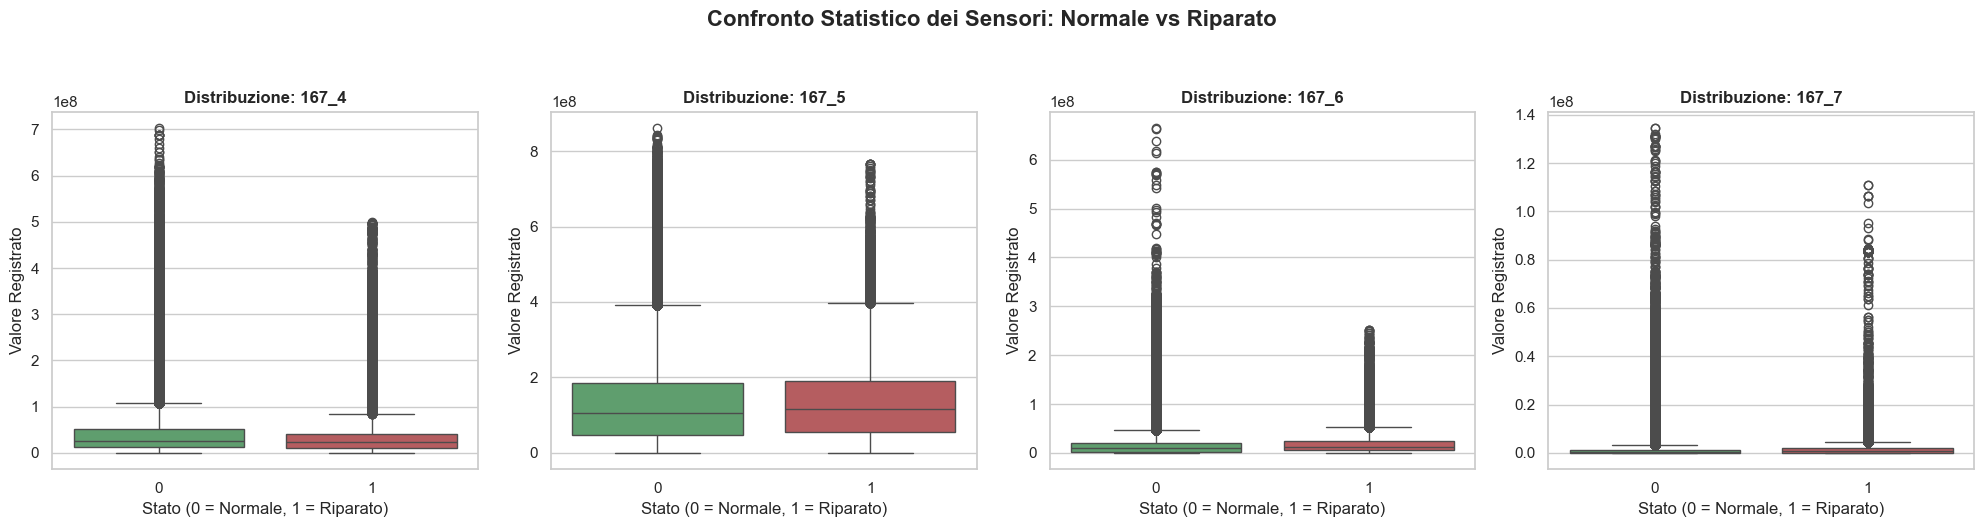

In [ ]:
# Selezioniamo le prime 4 feature operative numeriche (escludendo vehicle_id, time_step e i target)
# Puoi modificare l'indice [2:6] per esplorare altri blocchi di feature (es. i bin degli istogrammi)
features_to_compare = train_op.select_dtypes(include=[np.number]).columns[2:6]

# Creiamo una griglia di subplot per i boxplot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        x='in_study_repair', 
        y=feature, 
        data=df_merged, 
        ax=axes[i], 
        palette=['#55A868', '#C44E52']
    )
    
    # Formattazione dei singoli grafici
    axes[i].set_title(f'Distribuzione: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Stato (0 = Normale, 1 = Riparato)')
    axes[i].set_ylabel('Valore Registrato')

plt.suptitle('Confronto Statistico dei Sensori: Normale vs Riparato', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 5. Mappa di Calore delle Correlazioni (Correlation Heatmap)

Nei dati operativi SCANIA sono presenti moltissime variabili. Calcoliamo la correlazione di Pearson per individuare eventuali ridondanze tra i sensori (multicollinearità) o per scoprire quali feature operative sono più linearmente correlate all'etichetta di guasto (`in_study_repair`). Per questioni di leggibilità, selezioniamo un sottoinsieme delle variabili più rappresentative.

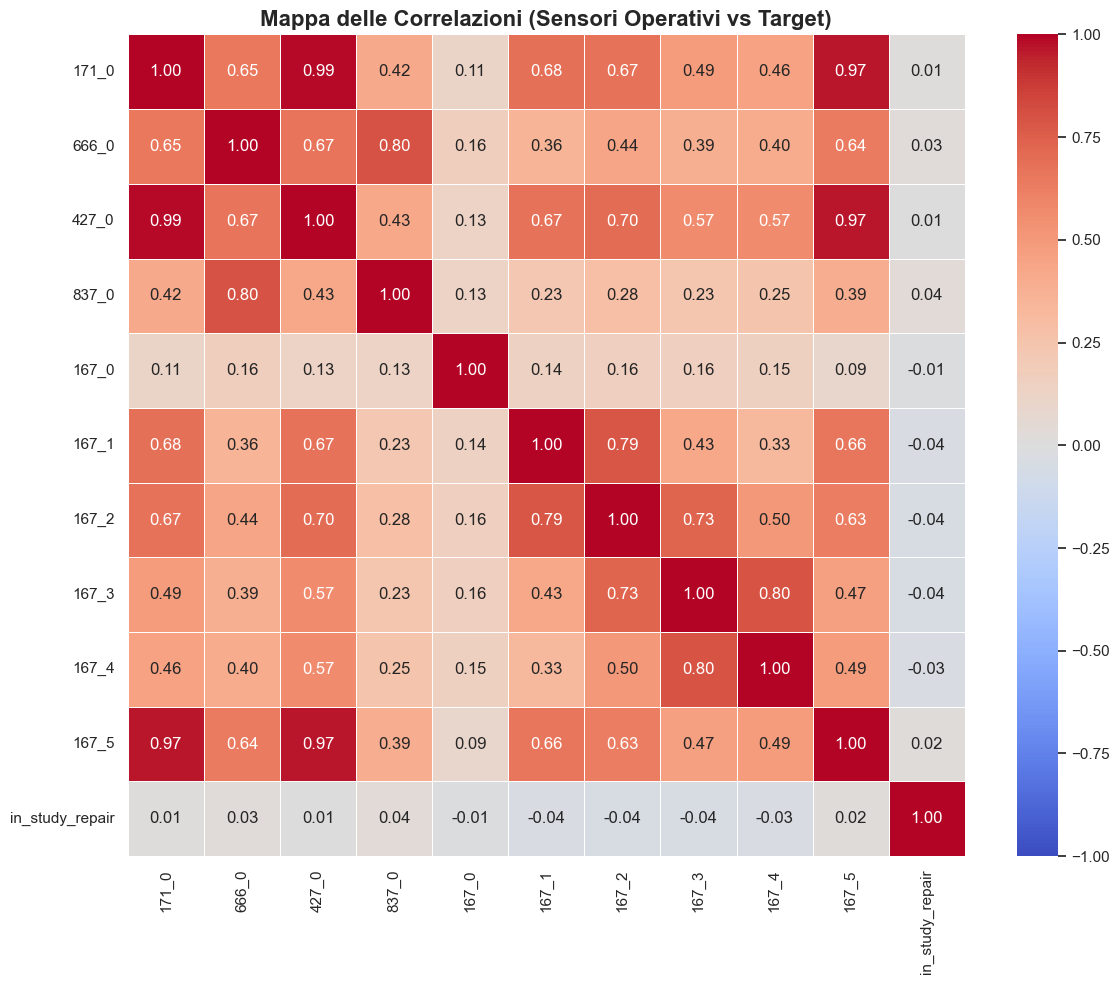

In [18]:
# Selezioniamo un sottoinsieme di variabili: le prime 10 feature numeriche e la variabile target
# (Se il dataset ha centinaia di colonne, una heatmap completa sarebbe illeggibile)
num_features = train_op.select_dtypes(include=[np.number]).columns[2:12].tolist()
cols_to_correlate = num_features + ['in_study_repair']

plt.figure(figsize=(12, 10))
corr_matrix = df_merged[cols_to_correlate].corr()

# Disegniamo la heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title("Mappa delle Correlazioni (Sensori Operativi vs Target)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Esplorazione del Dominio (Specifiche vs Sensori)

Ispirandoci alle tecniche di *Transfer Learning*, vogliamo verificare se la distribuzione fisica dei dati operativi subisce una "deriva" a seconda delle specifiche del veicolo. Uniamo i dati operativi con le configurazioni di fabbrica per scoprire se, ad esempio, una determinata categoria di camion stressa maggiormente il "Component X" rispetto ad un'altra.

Integrazione delle Specifiche Tecniche per l'Analisi di Dominio...


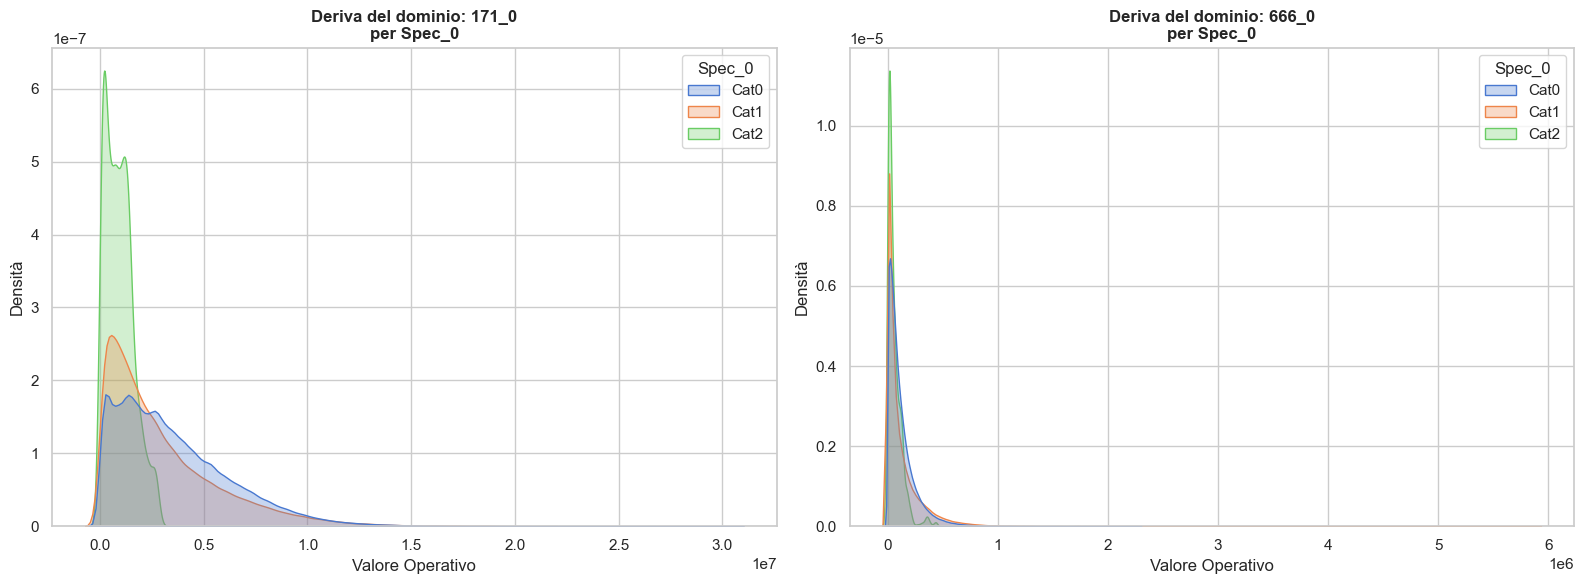

In [19]:
print("Integrazione delle Specifiche Tecniche per l'Analisi di Dominio...")

# Uniamo il dataset merged (Operativi + TTE) con le Specifiche Tecniche
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

# Selezioniamo una colonna categorica dalle specifiche (es. la classe del veicolo)
cat_col_domain = train_specs.select_dtypes(include=['object']).columns[0]

# Selezioniamo un paio di feature operative da analizzare
features_for_domain = num_features[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, feature in enumerate(features_for_domain):
    # Generiamo un Kernel Density Estimate (KDE) plot
    sns.kdeplot(
        data=df_full, 
        x=feature, 
        hue=cat_col_domain, 
        ax=axes[i], 
        common_norm=False, 
        fill=True, 
        alpha=0.3
    )
    axes[i].set_title(f'Deriva del dominio: {feature}\nper {cat_col_domain}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valore Operativo')
    axes[i].set_ylabel('Densità')

plt.tight_layout()
plt.show()